# Sistem Klasifikasi Citra Bunga Menggunakan Multi-Layer Perceptron (MLP)

**Mata Kuliah:** Pengolahan Citra Digital (SIF202)

**Semester / Tahun Ajaran:** Genap 2025/2026

**Dosen Pengampu:** Teuku Rizky Noviandy, S.Kom., M.Kom.

## Identitas Mahasiswa

- **Nama:** Roja Hubbil Khairi
- **NIM:** 24146036

In [1]:
# Import Pustaka
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Konfigurasi
NIM_MAHASISWA = 24146036
NAMA_MAHASISWA = "Roja Hubbil Khairi"
DATA_PATH = "../dataset/flowers"
IMG_SIZE = (64, 64)
CLASSES = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
CLASS_LABELS = ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip']

# Format desimal koma untuk grafik (sesuai kaidah Bahasa Indonesia)
import locale
locale.setlocale(locale.LC_ALL, 'id_ID.UTF-8')
import matplotlib as mpl
mpl.rcParams['axes.formatter.use_locale'] = True

## 1. Data Loading & Preprocessing

Dataset Flowers Recognition dari Kaggle dimuat dari direktori lokal. Setiap citra:
- Di-resize ke ukuran 64×64 piksel
- Dinormalisasi nilai piksel ke rentang [0, 1]
- Di-flatten menjadi vektor 1D (64×64×3 = 12288 fitur)

In [3]:
def load_and_preprocess(data_path, img_size):
    X = []
    y = []

    for idx, cls in enumerate(CLASSES):
        cls_path = os.path.join(data_path, cls)
        count = 0
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(cls_path, fname)
                img = Image.open(img_path).convert('RGB')
                img = img.resize(img_size)
                img_array = np.array(img, dtype=np.float32) / 255.0
                X.append(img_array.flatten())
                y.append(idx)
                count += 1
        print(f"Kelas '{cls}': {count} citra dimuat")

    return np.array(X), np.array(y)

In [4]:
print("Memuat dataset...")
X, y = load_and_preprocess(DATA_PATH, IMG_SIZE)
print(f"\nTotal dataset: {X.shape[0]} citra")
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Rentang nilai piksel: [{X.min():.3f}, {X.max():.3f}]")

Memuat dataset...


Kelas 'daisy': 764 citra dimuat


Kelas 'dandelion': 1052 citra dimuat


Kelas 'rose': 784 citra dimuat


Kelas 'sunflower': 733 citra dimuat


Kelas 'tulip': 984 citra dimuat

Total dataset: 4317 citra
Shape X: (4317, 12288)
Shape y: (4317,)
Rentang nilai piksel: [0.000, 1.000]


## 2. Data Splitting

Dataset dibagi menjadi:
- **80% data latih (training)**
- **20% data uji (testing)**

Menggunakan `random_state = NIM` untuk reproducibility.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=NIM_MAHASISWA
)

print("=== Pembagian Dataset ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"\nProporsi training: {len(y_train)/len(y)*100:.1f}%")
print(f"Proporsi testing:  {len(y_test)/len(y)*100:.1f}%")

=== Pembagian Dataset ===
X_train: (3453, 12288)
X_test:  (864, 12288)
y_train: (3453,)
y_test:  (864,)

Proporsi training: 80.0%
Proporsi testing:  20.0%


## 3. Model Training — Multi-Layer Perceptron (MLP)

Arsitektur MLP:
- **Input layer:** 12288 neuron (fitur hasil flattening)
- **Hidden layer 1:** 128 neuron, aktivasi ReLU
- **Hidden layer 2:** 64 neuron, aktivasi ReLU
- **Output layer:** 5 neuron (softmax — 5 kelas bunga)
- **Optimizer:** Adam
- **Max iter:** 500

In [6]:
print("Inisialisasi dan training MLP...")
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=NIM_MAHASISWA
)

mlp.fit(X_train, y_train)
print("Training selesai.")

Inisialisasi dan training MLP...


Training selesai.


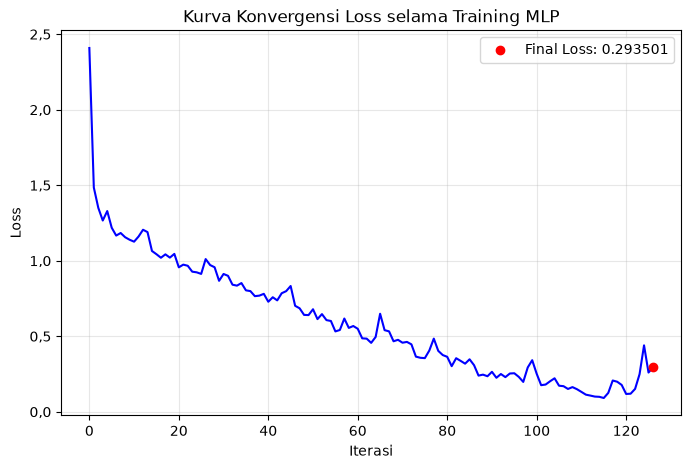

In [7]:
# Plot Kurva Loss
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, color='blue', linewidth=1.5)
plt.scatter(len(mlp.loss_curve_) - 1, mlp.loss_,
            color='red', zorder=5, label=f'Final Loss: {mlp.loss_:.6f}')
plt.xlabel('Iterasi')
plt.ylabel('Loss')
plt.title('Kurva Konvergensi Loss selama Training MLP')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluasi Model

Evaluasi menggunakan data uji (testing) dengan metrik:
- Akurasi
- Precision
- Recall
- F1-Score

Disajikan dengan format 4 digit desimal (`digits=4`).

In [8]:
y_pred = mlp.predict(X_test)

print("=" * 60)
print("         CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, digits=4))
print("=" * 60)

         CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.5211    0.2327    0.3217       159
           1     0.4141    0.8039    0.5467       204
           2     0.5429    0.3563    0.4302       160
           3     0.5649    0.5762    0.5705       151
           4     0.4783    0.3474    0.4024       190

    accuracy                         0.4757       864
   macro avg     0.5043    0.4633    0.4543       864
weighted avg     0.4981    0.4757    0.4562       864



Confusion Matrix (Numerik):
[[ 37  87  12  14   9]
 [ 10 164   1  18  11]
 [  9  44  57   8  42]
 [  7  44   3  87  10]
 [  8  57  32  27  66]]


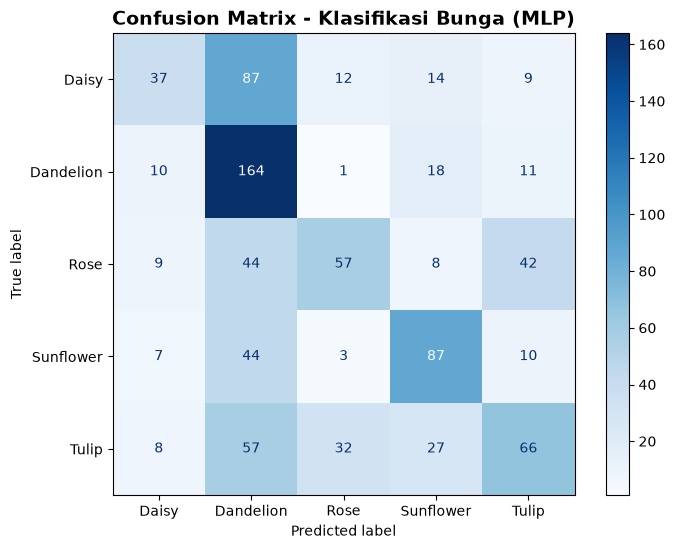

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)

print("Confusion Matrix (Numerik):")
print(cm)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Klasifikasi Bunga (MLP)', fontsize=14, fontweight='bold')
plt.savefig('../image_0.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Visualisasi Sampel Prediksi

Menampilkan 25 sampel acak dari data uji (5 sampel per kelas).
- **Hijau:** Prediksi benar
- **Merah:** Prediksi salah

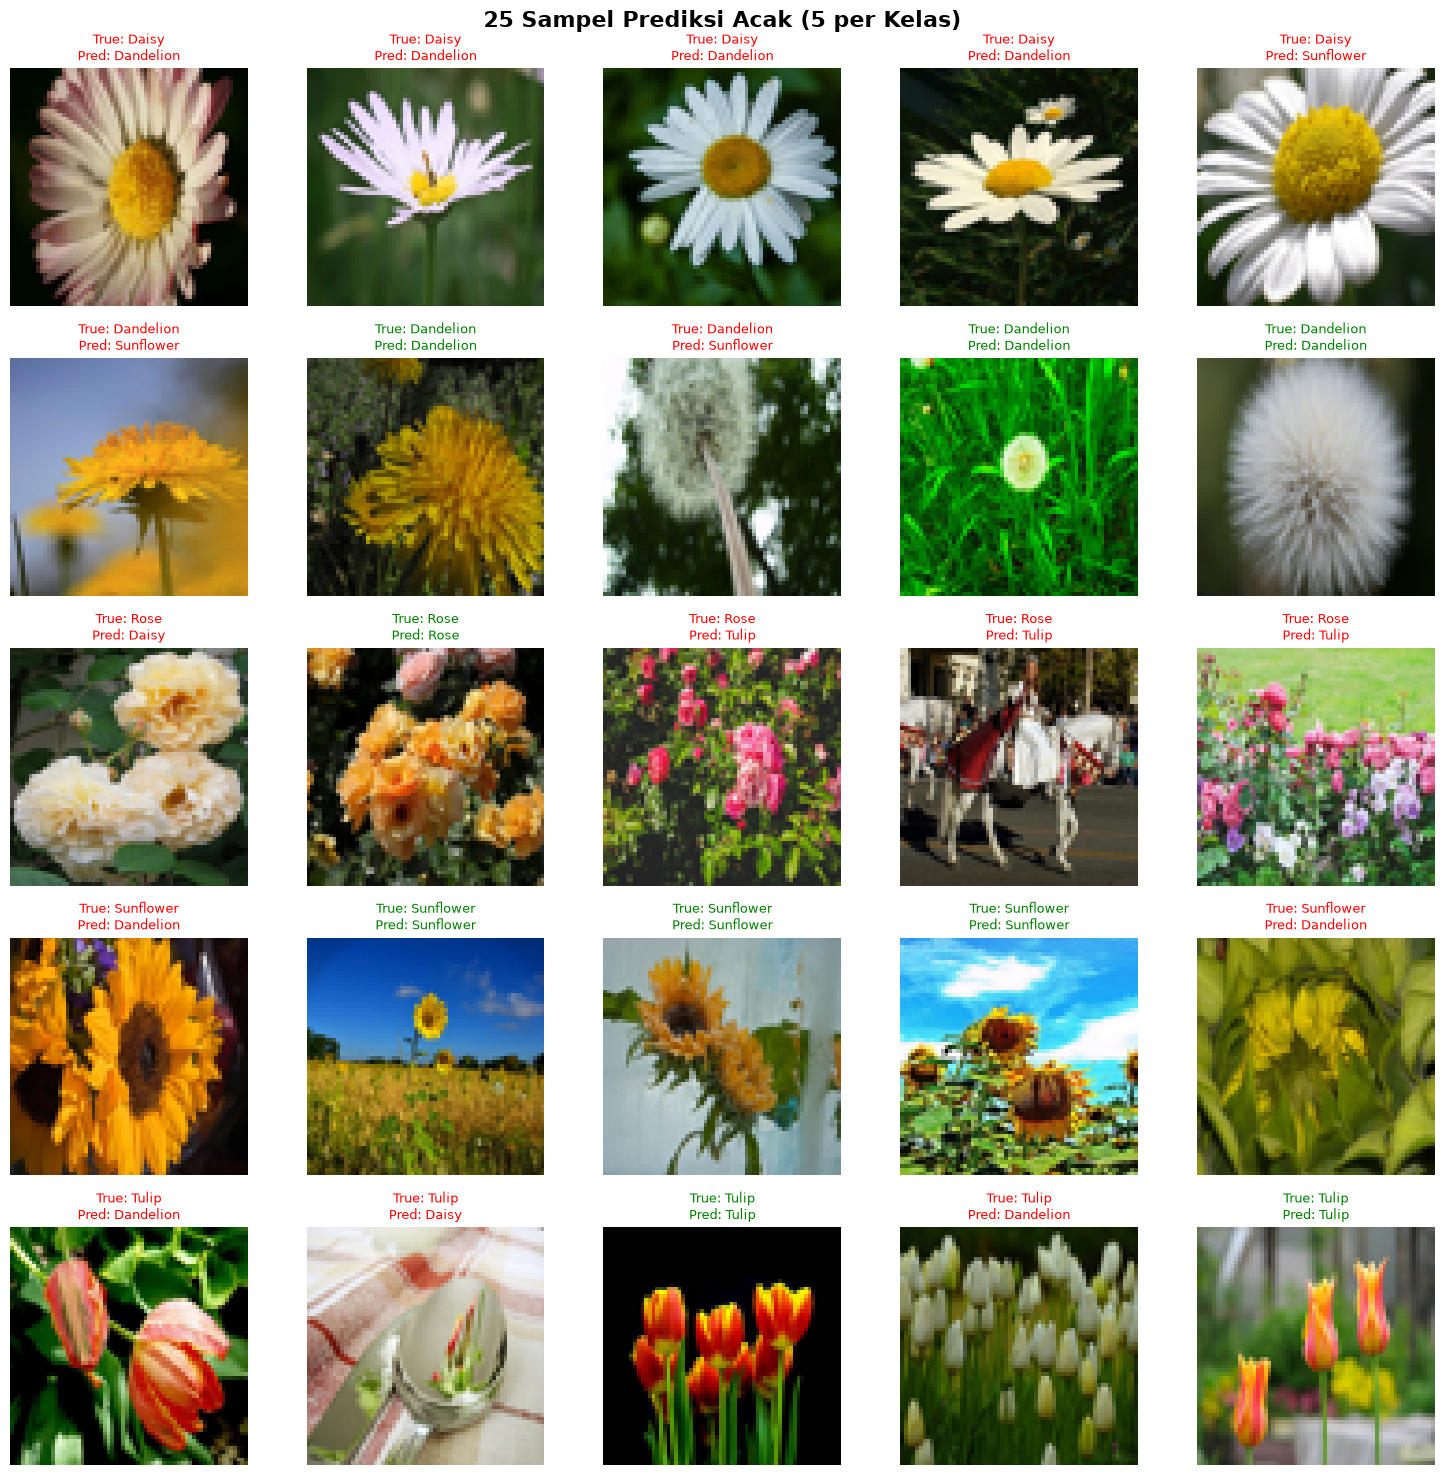

In [10]:
n_samples_per_class = 5
fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for i in range(5):
    cls_mask = (y_test == i)
    cls_indices = np.where(cls_mask)[0]
    selected = np.random.choice(cls_indices, n_samples_per_class, replace=False)

    for j, idx in enumerate(selected):
        img_vector = X_test[idx]
        img = img_vector.reshape(64, 64, 3)
        ax = axes[i][j]
        ax.imshow(img)
        ax.axis('off')
        true_label = CLASS_LABELS[y_test[idx]]
        pred_label = CLASS_LABELS[y_pred[idx]]
        color = 'green' if y_test[idx] == y_pred[idx] else 'red'
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=9, color=color)

plt.suptitle('25 Sampel Prediksi Acak (5 per Kelas)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../image_1.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Ringkasan Hasil

| Metrik | Nilai |
|---|---|
| Algoritma | Multi-Layer Perceptron (MLP) |
| Ukuran Citra | 64 × 64 × 3 |
| Jumlah Fitur | 12288 |
| Data Latih | ... sampel |
| Data Uji | ... sampel |
| Akurasi | ... |

*Detail metrik Precision, Recall, dan F1-Score dapat dilihat pada Classification Report di atas.*

In [11]:
# Ringkasan numerik akhir
accuracy = mlp.score(X_test, y_test)
print("=" * 50)
print("           RINGKASAN HASIL")
print("=" * 50)
print(f"Algoritma        : Multi-Layer Perceptron (MLP)")
print(f"Ukuran Input     : {IMG_SIZE[0]} x {IMG_SIZE[1]} x 3")
print(f"Jumlah Fitur     : {X.shape[1]}")
print(f"Total Data       : {len(y)} citra")
print(f"Data Latih       : {len(y_train)} citra ({len(y_train)/len(y)*100:.1f}%)")
print(f"Data Uji         : {len(y_test)} citra ({len(y_test)/len(y)*100:.1f}%)")
print(f"Akurasi          : {accuracy:.4f}")
print(f"Iterasi Training : {mlp.n_iter_}")
print(f"Loss Akhir       : {mlp.loss_:.6f}")
print("=" * 50)

           RINGKASAN HASIL
Algoritma        : Multi-Layer Perceptron (MLP)
Ukuran Input     : 64 x 64 x 3
Jumlah Fitur     : 12288
Total Data       : 4317 citra
Data Latih       : 3453 citra (80.0%)
Data Uji         : 864 citra (20.0%)
Akurasi          : 0.4757
Iterasi Training : 127
Loss Akhir       : 0.293501
